<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/Time-Series-and-Forecasting/TimeSeriesAndForecasting/Regime_Switching_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# --- 1. GET DATA ---
ticker = 'SPY'
df = yf.download(ticker, start='2000-01-01', end='2024-01-01', progress=False, auto_adjust=False)

# Handle MultiIndex if necessary
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Calculate Weekly Returns (Less noise than daily, easier to detect regimes)
df_weekly = df['Adj Close'].resample('W').last().pct_change().dropna() * 100

# --- 2. FIT MARKOV SWITCHING MODEL ---
# We assume 2 regimes (k_regimes=2)
# switching_variance=True: The "Risk" changes between regimes (Critical!)
# switching_trend=True: The "Expected Return" changes between regimes
model = sm.tsa.MarkovRegression(df_weekly, k_regimes=2, trend='c', switching_variance=True)
res = model.fit()

print(res.summary())

                        Markov Switching Model Results                        
Dep. Variable:              Adj Close   No. Observations:                 1251
Model:               MarkovRegression   Log Likelihood               -2725.257
Date:                Mon, 19 Jan 2026   AIC                           5462.514
Time:                        03:52:27   BIC                           5493.304
Sample:                    01-16-2000   HQIC                          5474.088
                         - 12-31-2023                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3524      0.056      6.283      0.000       0.242       0.462
sigma2         2.2479      0.168     13.373      0.0

In [ ]:
# --- 3. EXTRACT PROBABILITIES ---
# smoothed_marginal_probabilities gives us the prob of being in Regime 0 vs Regime 1
df_regime = pd.DataFrame(index=df_weekly.index)
df_regime['Return'] = df_weekly
df_regime['Prob_Crash_Regime'] = res.filtered_marginal_probabilities[1] # [0] is calm, [1] is volatile
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2000-01-03,91.617058,145.4375,148.25000,143.875000,148.25000,8164300
2000-01-04,88.034248,139.7500,144.06250,139.640625,143.53125,8089800
2000-01-05,88.191750,140.0000,141.53125,137.250000,139.93750,12177900
2000-01-06,86.774384,137.7500,141.50000,137.750000,139.62500,6227200
2000-01-07,91.813927,145.7500,145.75000,140.062500,140.31250,8066500


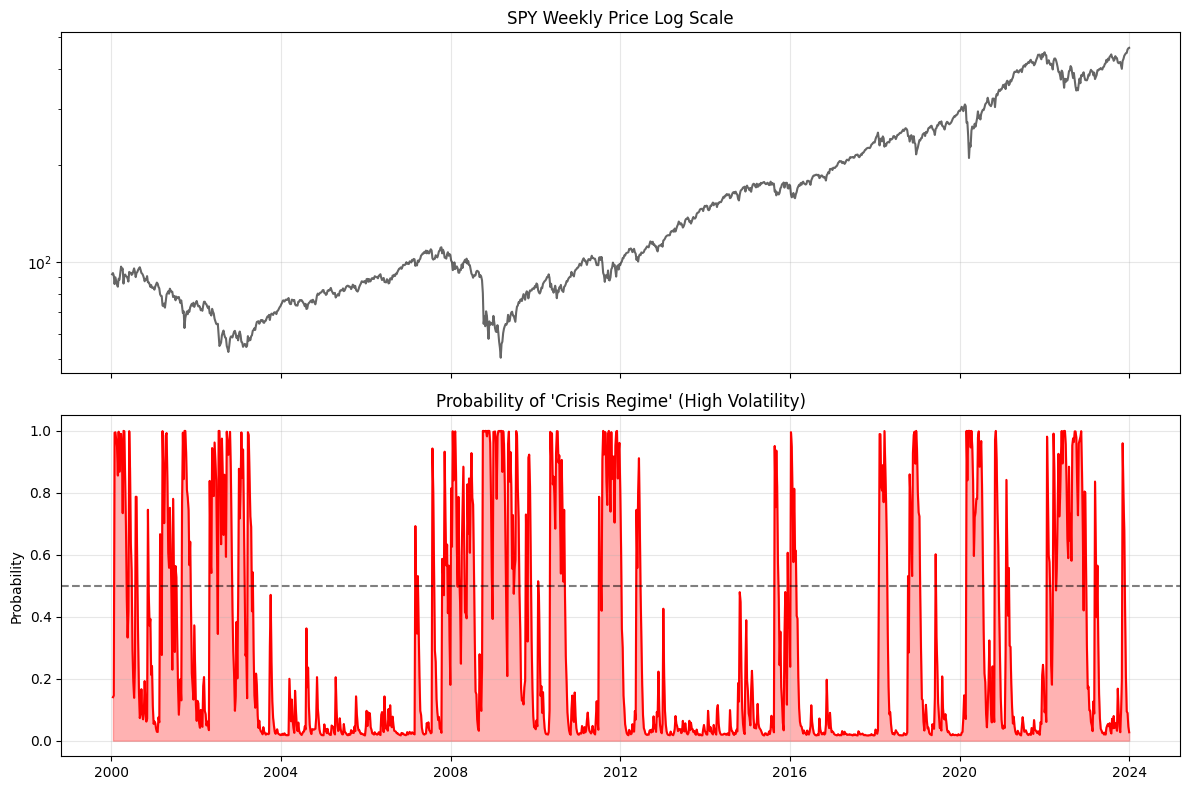

In [ ]:
# --- 4. VISUALIZATION ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot Stock Price (Re-aligned to weekly)
price_weekly = df['Adj Close'].resample('W').last()
axes[0].plot(price_weekly.index, price_weekly, color='black', alpha=0.6)
axes[0].set_title(f"{ticker} Weekly Price Log Scale")
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Plot Regime Probability
axes[1].plot(df_regime.index, df_regime['Prob_Crash_Regime'], color='red', linewidth=1.5)
axes[1].set_title("Probability of 'Crisis Regime' (High Volatility)")
axes[1].set_ylabel("Probability")
axes[1].axhline(0.5, color='black', linestyle='--', alpha=0.5) # The 50% "tipping point"
axes[1].fill_between(df_regime.index, 0, df_regime['Prob_Crash_Regime'], color='red', alpha=0.3)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# --- 5. STRATEGY BACKTEST ---

# Download TLT (Hedge Asset)
hedge_ticker = 'TLT'
df_hedge = yf.download(hedge_ticker, start='2000-01-01', end='2024-01-01', progress=False, auto_adjust=False)
if isinstance(df_hedge.columns, pd.MultiIndex):
    df_hedge.columns = df_hedge.columns.get_level_values(0)

# Resample Hedge to Weekly to match SPY
hedge_weekly = df_hedge['Adj Close'].resample('W').last().pct_change().dropna() * 100

# Align DataFrames
strategy_data = pd.DataFrame(index=df_weekly.index)
strategy_data['SPY_Ret'] = df_weekly
strategy_data['TLT_Ret'] = hedge_weekly
strategy_data['Prob_Crash'] = df_regime['Prob_Crash_Regime']


# Drop NaNs (TLT started later than SPY)
strategy_data.dropna(inplace=True)

# DEFINE SIGNALS
# We shift signals by 1 because we use "Today's" regime to trade "Tomorrow"
strategy_data['Signal_Safe'] = (strategy_data['Prob_Crash'] < 0.50).astype(int)

# CALC RETURNS
# If Safe: Return = SPY. If Danger: Return = TLT.
strategy_data['Strat_Ret'] = (
    strategy_data['Signal_Safe'].shift(1) * strategy_data['SPY_Ret'] +
    (1 - strategy_data['Signal_Safe'].shift(1)) * strategy_data['TLT_Ret']
)

# Benchmark (50/50 Split Constant)
strategy_data['Benchmark_50_50'] = 0.5 * strategy_data['SPY_Ret'] + 0.5 * strategy_data['TLT_Ret']
strategy_data.head()

,SPY_Ret,TLT_Ret,Prob_Crash,Signal_Safe,Strat_Ret,Benchmark_50_50
Date,,,,,,
2002-08-11,5.184886,1.228267,0.975283,0,NaN,3.206576
2002-08-18,2.114175,0.212164,0.866019,0,0.212164,1.163169
2002-08-25,1.480356,0.987458,0.664187,0,0.987458,1.233907
2002-09-01,-2.980978,1.373671,0.858635,0,1.373671,-0.803653
2002-09-08,-1.939411,0.868483,0.823178,0,0.868483,-0.535464


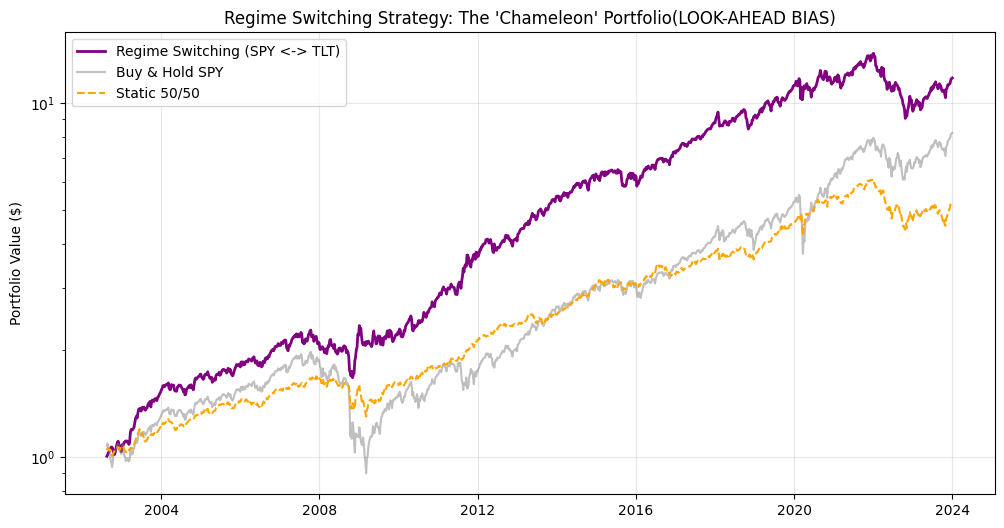

In [ ]:
# --- 6. EQUITY CURVE ---
initial_balance = 1
strategy_data['Equity_Regime'] = initial_balance * (1 + strategy_data['Strat_Ret']/100).cumprod()
strategy_data['Equity_SPY'] = initial_balance * (1 + strategy_data['SPY_Ret']/100).cumprod()
strategy_data['Equity_50_50'] = initial_balance * (1 + strategy_data['Benchmark_50_50']/100).cumprod()
strategy_data.dropna(inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(strategy_data['Equity_Regime'], label='Regime Switching (SPY <-> TLT)', color='purple', linewidth=2)
plt.plot(strategy_data['Equity_SPY'], label='Buy & Hold SPY', color='gray', alpha=0.5)
plt.plot(strategy_data['Equity_50_50'], label='Static 50/50', color='orange', linestyle='--')

plt.title("Regime Switching Strategy: The 'Chameleon' Portfolio(LOOK-AHEAD BIAS)")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.yscale('log') # Log scale helps see the difference over long periods
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# --- 7. METRICS ---
def quick_stats(series):
    ret = (series.iloc[-1]/series.iloc[0]) - 1
    # Simple Sharpe (Weekly) -> * sqrt(52)
    daily_ret = series.pct_change()
    sharpe = daily_ret.mean() / daily_ret.std() * np.sqrt(52)
    return ret, sharpe

r_reg, s_reg = quick_stats(strategy_data['Equity_Regime'])
r_spy, s_spy = quick_stats(strategy_data['Equity_SPY'])

print(f"Regime Strat | Total Ret: {r_reg*100:.0f}% | Sharpe: {s_reg:.2f}")
print(f"SPY Hold     | Total Ret: {r_spy*100:.0f}% | Sharpe: {s_spy:.2f}")

Regime Strat | Total Ret: 1075% | Sharpe: 0.88
SPY Hold     | Total Ret: 667% | Sharpe: 0.63


# Integrating with XGBOOST

Fitting Markov Regime Model (Weekly)...
Data Shape after merge: (3512, 8)
Price            Close  Regime_Prob
Date                               
2010-01-19  115.059998     0.622902
2010-01-20  113.889999     0.622902
2010-01-21  111.699997     0.622902
2010-01-22  109.209999     0.622902
2010-01-25  109.769997     0.719867
TRAIN DF
Price       Adj Close       Close        High         Low        Open  \
Date                                                                    
2010-02-05  80.023666  106.660004  106.879997  104.580002  106.559998   
2010-02-08  79.445961  105.889999  107.330002  105.809998  106.739998   
2010-02-09  80.443810  107.220001  108.150002  106.269997  107.129997   
2010-02-10  80.286285  107.010002  107.599998  106.110001  107.050003   
2010-02-11  81.126526  108.129997  108.250000  106.250000  106.870003   

Price          Volume   Log_Ret  Regime_Prob  Vol_Proxy  RSI_Proxy    Mom_10  \
Date                                                                     

/tmp/ipython-input-2809567435.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Pred_Vol'] = model.predict(test[features])


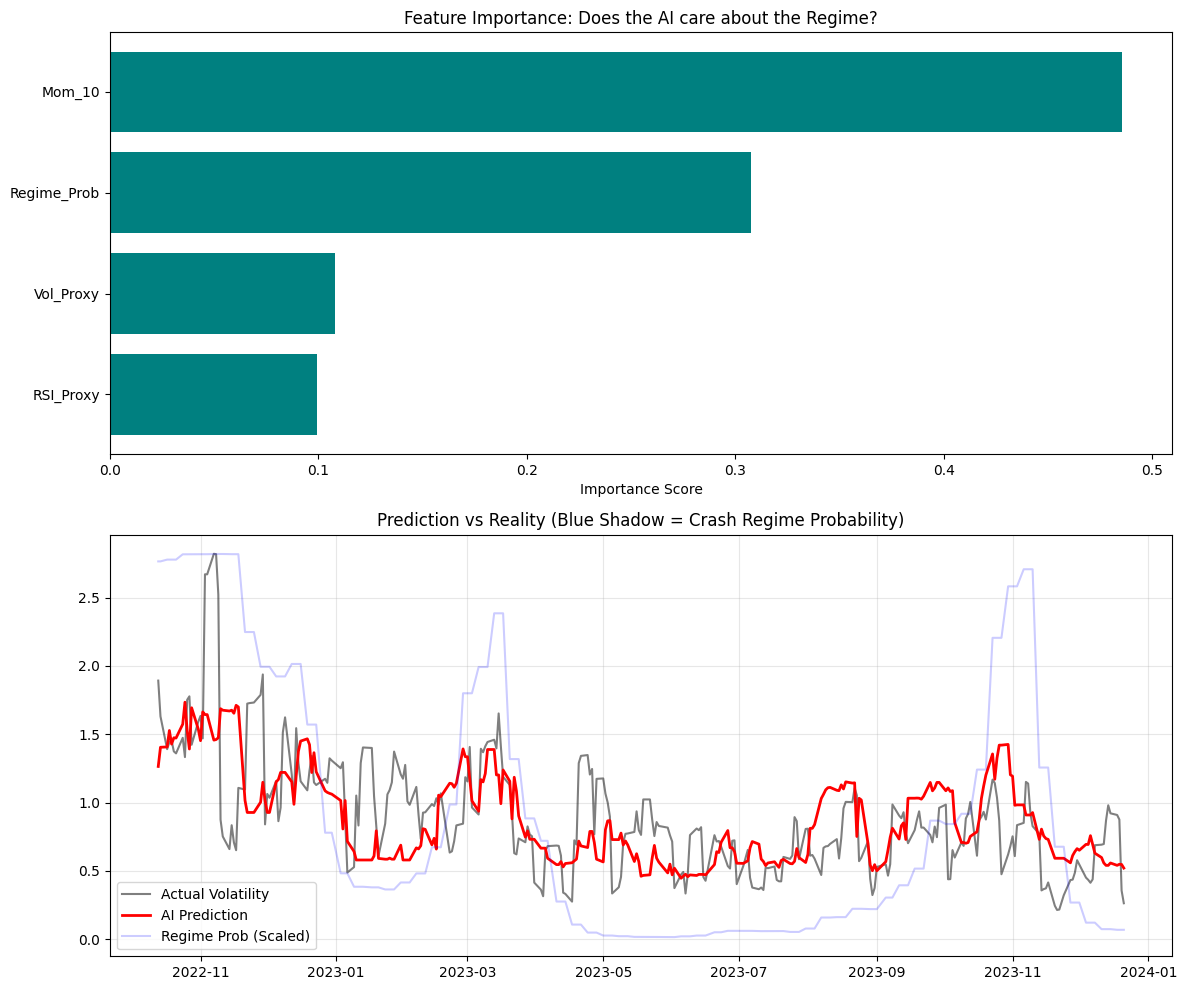

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import xgboost as xgb
import matplotlib.pyplot as plt
from xgboost import XGBRegressor, plot_importance
from sklearn.metrics import mean_squared_error, r2_score

# --- 1. DATA INGESTION ---
ticker = 'SPY'
print(f"Downloading data for {ticker}...")
df = yf.download(ticker, start='2010-01-01', end='2024-01-01', progress=False, auto_adjust=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Calculate Daily Returns
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1)) * 100
df.dropna(inplace=True)

# --- 2. REGIME DETECTION (THE MACRO BRAIN) ---
# We calculate Regimes on WEEKLY data (less noise), then map it back to DAILY.

print("Fitting Markov Regime Model (Weekly)...")
# Resample to Weekly
df_weekly = df['Adj Close'].resample('W').last().pct_change().dropna() * 100

# Fit Markov Model (2 Regimes)
# switching_variance=True is key: It detects "High Vol" vs "Low Vol" regimes
model_markov = sm.tsa.MarkovRegression(df_weekly, k_regimes=2, trend='c', switching_variance=True)
res_markov = model_markov.fit()

# Extract the "Crash Probability" (Regime 1)
# Note: Sometimes Regime 0 is the crash, sometimes Regime 1.
# We assume the one with higher variance is the crash.
regime_vol = res_markov.params[['sigma2[0]', 'sigma2[1]']]
crash_regime_idx = regime_vol.idxmax().replace('sigma2[', '').replace(']', '')
crash_regime_idx = int(crash_regime_idx)

# Get probabilities for the crash regime
weekly_probs = res_markov.smoothed_marginal_probabilities[crash_regime_idx]
weekly_probs.name = 'Regime_Prob'

# --- 3. MERGE MACRO (WEEKLY) WITH MICRO (DAILY) ---

# A. FIX TIMEZONES (Common cause of merge failures)
# Ensure both indices are timezone-naive to prevent mismatch errors
if df.index.tz is not None:
    df.index = df.index.tz_localize(None)
if weekly_probs.index.tz is not None:
    weekly_probs.index = weekly_probs.index.tz_localize(None)

# B. REINDEX INSTEAD OF JOIN
# We take the weekly probabilities and force them to conform to the daily index.
# method='ffill' means: "If today is Tuesday, use the value from the previous Sunday."
df['Regime_Prob'] = weekly_probs.reindex(df.index, method='ffill')

# C. HANDLE THE START
# The first few days/weeks might be NaN because the weekly model needs a lag.
# We drop only rows where 'Regime_Prob' is missing.
df.dropna(subset=['Regime_Prob'], inplace=True)

# Debug Print to confirm it worked
print(f"Data Shape after merge: {df.shape}")
print(df[['Close', 'Regime_Prob']].head())

# --- 4. FEATURE ENGINEERING (THE MICRO BRAIN) ---

# A. GARCH Feature (The Baseline)
# (Using EWMA proxy here for speed, but you can insert the real GARCH code from previous step)
df['Vol_Proxy'] = df['Log_Ret'].ewm(span=20).std()

# B. Technicals
df['RSI_Proxy'] = df['Close'] / df['Close'].rolling(14).mean()
df['Mom_10'] = df['Close'].pct_change(10)

# C. The Target: Future Realized Volatility (Next 5 Days)
df['Target_Vol'] = df['Log_Ret'].rolling(5).std().shift(-5)

df.dropna(inplace=True)

# --- 5. TRAIN XGBOOST (CONTEXT AWARE) ---

# Train/Test Split (Time Series Split)
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

features = ['Vol_Proxy', 'RSI_Proxy', 'Mom_10', 'Regime_Prob']
target = 'Target_Vol'

print("TRAIN DF")
print(train.head())

print("Training XGBoost with Regime Awareness...")
model = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model.fit(train[features], train[target])

# --- 6. PREDICT & EVALUATE ---
test['Pred_Vol'] = model.predict(test[features])

# Metrics
print(test[target], test['Pred_Vol'])
rmse = np.sqrt(mean_squared_error(test[target], test['Pred_Vol']))
r2 = r2_score(test[target], test['Pred_Vol'])

print(f"\n--- RESULTS ---")
print(f"R-Squared: {r2:.4f} (Higher is better)")
print(f"RMSE:      {rmse:.4f}")

# --- 7. VISUALIZATION ---
plt.figure(figsize=(12, 10))

# Plot 1: Feature Importance
# Does the AI care about the Regime? (It should be high up)
plt.subplot(2, 1, 1)
sorted_idx = model.feature_importances_.argsort()
plt.barh(np.array(features)[sorted_idx], model.feature_importances_[sorted_idx], color='teal')
plt.title("Feature Importance: Does the AI care about the Regime?")
plt.xlabel("Importance Score")

# Plot 2: Prediction vs Reality in a Crash
plt.subplot(2, 1, 2)
# Zoom into the last 200 days or a specific volatile period
subset = test.iloc[-300:]
plt.plot(subset.index, subset[target], color='black', alpha=0.5, label='Actual Volatility')
plt.plot(subset.index, subset['Pred_Vol'], color='red', linewidth=2, label='AI Prediction')
plt.plot(subset.index, subset['Regime_Prob'] * subset[target].max(), color='blue', alpha=0.2, label='Regime Prob (Scaled)')

plt.title("Prediction vs Reality (Blue Shadow = Crash Regime Probability)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

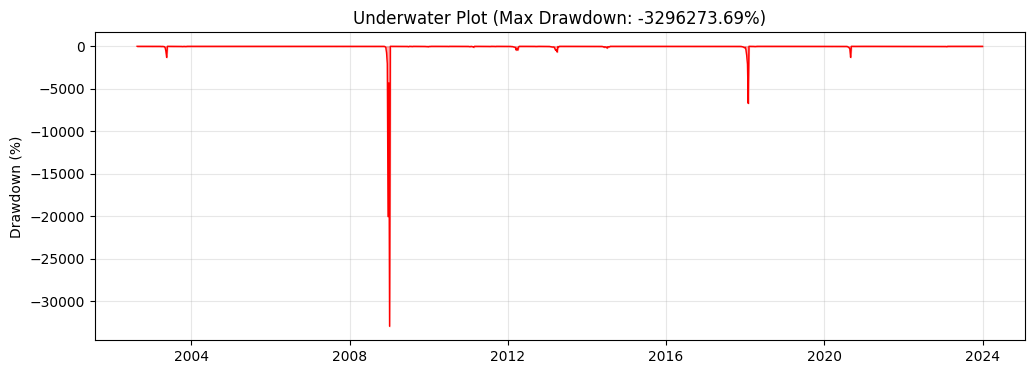

In [ ]:
# Calculate Drawdown
# 1. Calculate Cumulative Wealth
wealth_index = (1 + strategy_data['Strat_Ret']).cumprod()
# 2. Calculate Previous Peak at every step
previous_peaks = wealth_index.cummax()
# 3. Calculate Drawdown (Percentage drop from peak)
drawdown = (wealth_index - previous_peaks) / previous_peaks

# PLOT
plt.figure(figsize=(12, 4))
plt.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.3)
plt.plot(drawdown.index, drawdown, color='red', linewidth=1)
plt.title(f"Underwater Plot (Max Drawdown: {drawdown.min()*100:.2f}%)")
plt.ylabel("Drawdown (%)")
plt.grid(True, alpha=0.3)
plt.show()

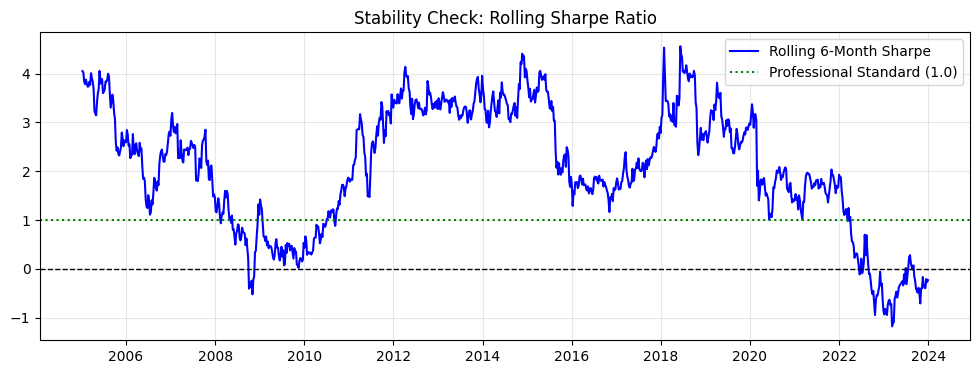

In [ ]:
# Rolling Sharpe (6-month window = 126 trading days)
rolling_sharpe = strategy_data['Strat_Ret'].rolling(126).mean() / strategy_data['Strat_Ret'].rolling(126).std() * np.sqrt(252)

plt.figure(figsize=(12, 4))
plt.plot(rolling_sharpe, color='blue', label='Rolling 6-Month Sharpe')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axhline(1.0, color='green', linestyle=':', label='Professional Standard (1.0)')
plt.title("Stability Check: Rolling Sharpe Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Information Coefficient (IC): 0.6762
P-Value: 0.0000


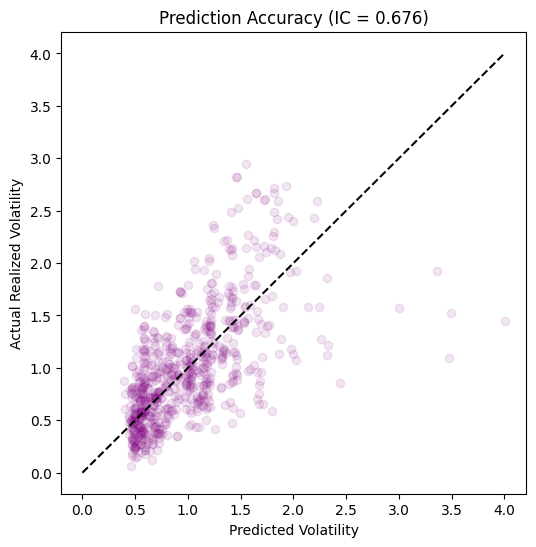

In [ ]:
from scipy.stats import spearmanr

# Calculate IC (Rank Correlation)
# We use Spearman Rank correlation because financial data often has outliers
ic, p_value = spearmanr(test['Pred_Vol'], test['Target_Vol'])

print(f"Information Coefficient (IC): {ic:.4f}")
print(f"P-Value: {p_value:.4f}")

# Visual Scatter
plt.figure(figsize=(6, 6))
plt.scatter(test['Pred_Vol'], test['Target_Vol'], alpha=0.1, color='purple')
plt.title(f"Prediction Accuracy (IC = {ic:.3f})")
plt.xlabel("Predicted Volatility")
plt.ylabel("Actual Realized Volatility")
# Add a 45-degree line (Perfect Prediction)
max_val = max(test['Pred_Vol'].max(), test['Target_Vol'].max())
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--')
plt.show()

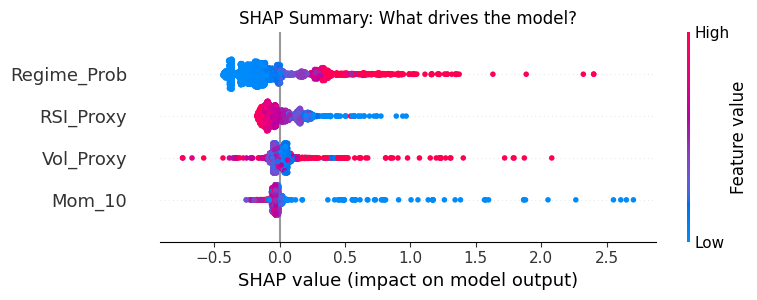

In [ ]:
import shap

# Initialize JavaScript (for notebook visualization)
shap.initjs()

# Create object that can calculate shap values
explainer = shap.TreeExplainer(model) # 'model' is your trained XGBoost
shap_values = explainer.shap_values(train[features])

# PLOT 1: Summary Plot (Global Importance)
# This is better than the bar chart because it shows DIRECTION.
# Red dots = High feature value, Blue dots = Low feature value.
# X-axis = Impact on prediction (Left = Lower Volatility, Right = Higher Volatility)
plt.title("SHAP Summary: What drives the model?")
shap.summary_plot(shap_values, train[features], show=False)
plt.show()